In [1]:
import pandas as pd
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Sentiment_Data.csv", encoding='ISO-8859-1')

In [13]:
# Function for regex-based text cleaning
def clean_text(text):
    text = re.sub(r"http\S+|www\S+", "", text)         # Remove URLs
    text = re.sub(r"@\w+", "", text)                   # Remove mentions
    text = re.sub(r"#\w+", "", text)                   # Remove hashtags
    text = re.sub(r"[^\w\s.,!?]", "", text)            # Remove emojis/special chars
    text = re.sub(r"\s+", " ", text).strip()           # Remove extra whitespace
    return text

In [14]:
# Apply cleaning
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_text)

In [15]:
# Label encoding
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Sentiment'])

In [16]:
# Class distribution (optional view)
print(df['Sentiment'].value_counts())

Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


In [17]:
# Train-test split (10% test set ensures ≥5000 samples)
train_df, test_df = train_test_split(df, test_size=0.1, stratify=df['Label'], random_state=42)

In [18]:
# Apply to the dataset
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_text)

In [19]:
# View result
print(df[['Tweet', 'Clean_Tweet']].head())

                                               Tweet  \
0  @_angelica_toy Happy Anniversary!!!....The Day...   
1  @McfarlaneGlenda Happy Anniversary!!!....The D...   
2  @thevivafrei @JustinTrudeau Happy Anniversary!...   
3  @NChartierET Happy Anniversary!!!....The Day t...   
4  @tabithapeters05 Happy Anniversary!!!....The D...   

                                         Clean_Tweet  
0  Happy Anniversary!!!....The Day the FreeDUMB D...  
1  Happy Anniversary!!!....The Day the FreeDUMB D...  
2  Happy Anniversary!!!....The Day the FreeDUMB D...  
3  Happy Anniversary!!!....The Day the FreeDUMB D...  
4  Happy Anniversary!!!....The Day the FreeDUMB D...  


In [36]:
# Install the emoji library
!pip install emoji


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 13.4 MB/s eta 0:00:00


In [38]:
# Import the emoji library
import emoji

In [39]:
# Example slang/abbreviation dictionary
slang_dict = {
    "u": "you",
    "ur": "your",
    "lol": "laugh out loud",
    "omg": "oh my god",
    "idk": "I don't know",
    "btw": "by the way",
    "gr8": "great",
    "thx": "thanks",
    "pls": "please",
    "imo": "in my opinion"
}


In [40]:
# Function to expand slang/abbreviations
def expand_slang(text):
    words = text.split()
    return ' '.join([slang_dict.get(word.lower(), word) for word in words])


In [41]:
# Function to remove emojis
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

In [42]:
# Combine everything: clean + expand + remove emojis
def clean_and_normalize(text):
    text = re.sub(r"http\S+|www\S+", "", text)         # Remove URLs
    text = re.sub(r"@\w+", "", text)                   # Remove mentions
    text = re.sub(r"#\w+", "", text)                   # Remove hashtags
    text = remove_emojis(text)                         # Remove emojis
    text = expand_slang(text)                          # Expand slang/abbreviations
    text = re.sub(r"[^\w\s.,!?]", "", text)            # Remove special characters
    text = re.sub(r"\s+", " ", text).strip()           # Normalize whitespace
    return text


In [44]:
# Apply to DataFrame
df = pd.read_csv("/content/drive/MyDrive/Sentiment_Data.csv", encoding='ISO-8859-1')
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_and_normalize)


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [46]:
# Encode sentiment labels (if not already done)
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Sentiment'])

In [48]:
# Perform stratified split (e.g., 10% test set = 45,000+ samples in your case)
train_df, test_df = train_test_split(
    df,
    test_size=0.1,                # 10% test set
    stratify=df['Label'],         # Ensure class distribution remains balanced
    random_state=42
)

In [49]:
# Confirm split sizes
print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")  # Should be > 5000

Train samples: 406198
Test samples: 45134


In [50]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
# Label Encoding
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Sentiment'])


In [52]:
# View mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:")
print(label_mapping)


Label Mapping:
{'Mild_Neg': np.int64(0), 'Mild_Pos': np.int64(1), 'Neutral': np.int64(2), 'Strong_Neg': np.int64(3), 'Strong_Pos': np.int64(4)}


In [53]:
# Class Balance (Value Counts)
print("\nClass Distribution:")
print(df['Sentiment'].value_counts())


Class Distribution:
Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


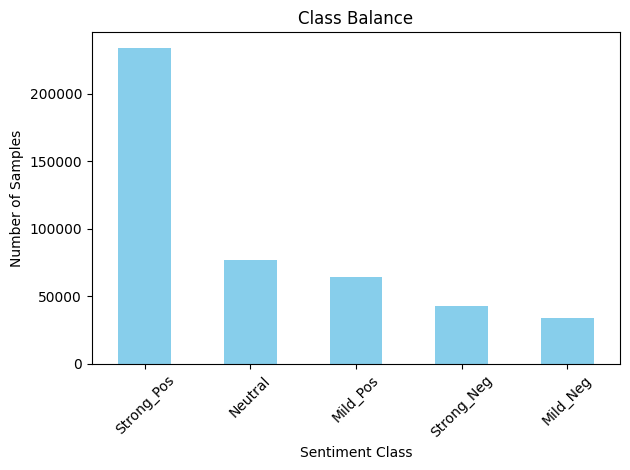

In [54]:

# Optional: Visualize class distribution
df['Sentiment'].value_counts().plot(kind='bar', title='Class Balance', color='skyblue')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()